## Step 1 — Compare Original vs Cleaned Dataset

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("resume_cleaned.csv")
df.head()

,ID,Resume_str,Resume_html,Category,char_length,word_length,Cleaned_Resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442,674,hr administrator/marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572,708,hr specialist u hr operation versatile medium ...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720,1017,hr director 20 year recruiting 15 plus year hu...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855,379,hr specialist dedicated driven dynamic 20 year...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172,1206,hr manager highlight hr hr department startup ...


In [9]:
sample = df.loc[0]

print("ORIGINAL RESUME:")
print("-" * 200)

print(sample["Resume_str"][:1500])

print("\n")


print("CLEANED RESUME:")
print("-" * 200)

print(sample["Cleaned_Resume"][:1500])

ORIGINAL RESUME:
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality 

## Step 2 — Length Reduction

In [10]:
df["Original_Length"] = df["Resume_str"].str.split().apply(len)

df["Cleaned_Length"] = df["Cleaned_Resume"].str.split().apply(len)

In [11]:
df[
    ["Original_Length", "Cleaned_Length"]
].head()

,Original_Length,Cleaned_Length
0,674,464
1,708,504
2,1017,686
3,379,248
4,1206,858


## Step 3 — Reduction Percentage

In [12]:
df["Reduction_%"] = (

    (df["Original_Length"] -

     df["Cleaned_Length"])

    / df["Original_Length"]

) * 100

In [13]:
df["Reduction_%"].describe()

count    2483.000000
mean       29.739039
std         4.301639
min         2.976809
25%        27.059668
50%        29.469274
75%        32.229738
max        51.318945
Name: Reduction_%, dtype: float64

## Step 4 — Histogram

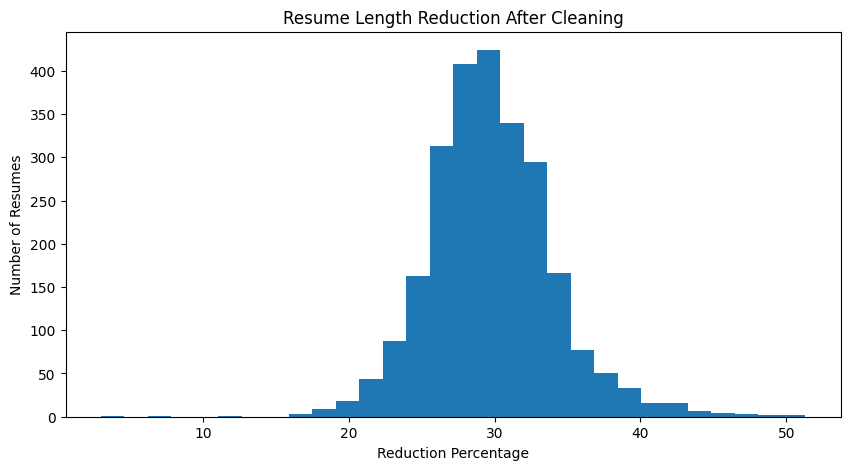

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["Reduction_%"],
    bins=30
)

plt.xlabel("Reduction Percentage")

plt.ylabel("Number of Resumes")

plt.title("Resume Length Reduction After Cleaning")

plt.show()

## Step 5 — Vocabulary Reduction

In [28]:
# Before Cleaning
original_vocab = set()

for resume in df["Resume_str"]:

    original_vocab.update(

        resume.lower().split()

    )
print("Before Cleaning:", len(original_vocab))

# After Cleaning
clean_vocab = set()

for resume in df["Cleaned_Resume"]:

    clean_vocab.update(

        resume.split()

    )

print("\nAfter Cleaning:", len(clean_vocab))


# Vocabularu Reduction:
print("\nVocabulary Reduction:", len(original_vocab) - len(clean_vocab))

Before Cleaning: 91386

After Cleaning: 53008

Vocabulary Reduction: 38378


## Step 6 — Longest Cleaned Resume

In [29]:
df["Cleaned_Length"].idxmax()

2110

In [30]:
idx = df["Cleaned_Length"].idxmax()

print(df.loc[idx, "Category"])

print(df.loc[idx, "Cleaned_Resume"][:2000])

PUBLIC-RELATIONS
bartender bartender 05/2018 – marketing public relation 10 year maintain proper adequate set-up bar daily basis responsible maintaining stock preparing storing garnish juice perishable ensure product quality attend stand ups prior function obtain detail order execute event flawlessly set breakdown mobile bar per hotel standard greets guest warm genuine hospitality promote up-sells product handle production consumption sheet assist cash bar set closing process perform general cleaning task adhere health department regulation bartender byron nelson golf tournament may 2019 dallas texas greet guest stock bar complete pre-opening requirement maintain clean bar area prepare serve alcoholic beverage according standard recipe comply basic safety sanitation requirement organizational product operate club po work large small event minimal supervision team environment complete pre-closing requirement assure local law club policy procedure service alcoholic beverage consistently 

## Step 7 — Shortest Resume

In [32]:
idx = df["Cleaned_Length"].idxmin()

print(df.loc[idx])

ID                                                          22965804
Resume_str                  CONSTRUCTION WORKER           Highlig...
Resume_html        <div class="fontsize fontface vmargins hmargin...
Category                                                CONSTRUCTION
char_length                                                      881
word_length                                                      113
Cleaned_Resume     construction worker highlight highly motivated...
Original_Length                                                  113
Cleaned_Length                                                    67
Reduction_%                                                40.707965
Name: 1930, dtype: object


## Step 8 — Most Frequent Words AFTER Cleaning

In [34]:
from collections import Counter

all_words = " ".join(

    df["Cleaned_Resume"]

).split()

counter = Counter(all_words)

counter.most_common(30)

[('management', 12003),
 ('customer', 11109),
 ('service', 8779),
 ('sale', 8384),
 ('business', 7896),
 ('project', 7747),
 ('system', 7139),
 ('team', 6923),
 ('new', 6330),
 ('client', 6312),
 ('development', 5721),
 ('training', 5667),
 ('manager', 5297),
 ('process', 5133),
 ('work', 5101),
 ('program', 4918),
 ('product', 4776),
 ('account', 4557),
 ('information', 4474),
 ('marketing', 4367),
 ('employee', 4323),
 ('office', 4313),
 ('financial', 4185),
 ('support', 4159),
 ('including', 4038),
 ('staff', 3929),
 ('report', 3843),
 ('data', 3716),
 ('operation', 3672),
 ('communication', 3666)]